## Sección I: Fonética. 

### ¿Qué es la fonética?
La fonética estudia la producción y la percepción de los sonidos o fonos, a esta rama de la lingüística le interesan cómo suenan las vocales y consonantes del español, además se preocupa por las cualidades fisiológicas, por lo que tiene una estrecha relación con ciencias como la anatomía, la fisiología y la acústica

### Ejercicio 1:


1. Con base en el sistema de búsqueda visto en la [práctica 1](https://github.com/umoqnier/cl-2026-2-lab/blob/main/notebooks/1_niveles_linguisticos_I.ipynb), dónde se recibe una palabra ortográfica y devuelve sus transcripciones fonológicas, proponga una solución para los casos en que la palabra buscada no se encuentra en el lexicón/diccionario.
    - ¿Cómo devolver o **aproximar** su transcripción fonológica?
    - Reutiliza el sistema de búsqueda visto en clase y mejóralo con esta funcionalidad.
    - Muestra al menos tres ejemplos
    

### Solucion:

Mi solucion consiste en volver el sistema mas robusto. El sistema original solo puede devolver ersultados si la palabra coincide caracter por caracter con el diccionario. Para mi solucion utilice la libreria difflib, de modo que si una palabra no es encontrada tal cual en el dataset de es_MX entonces se recorre las llaves del diccionario calculando la similitud de caracteres, se selecciona la palabra con mayor puntaje de similitud (con un umbral de 0.6 para reducir casos absurdos) y se devuelve la representacion IPA de la palabra seleccionada.

In [16]:
import requests as r
import http
import difflib  # para calcular similitudes entre cadenas

def download_ipa_corpus(iso_lang: str) -> str:
    IPA_URL = "https://raw.githubusercontent.com/open-dict-data/ipa-dict/master/data/{lang}.txt"
    response = r.get(IPA_URL.format(lang=iso_lang))
    if response.status_code != http.HTTPStatus.OK:
        print(f"ERROR on {iso_lang} :(")
        return ""
    return response.text

def parse_response(response: str) -> dict:
    ipa_list = response.rstrip().split("\n")
    result = {}
    for item in ipa_list:
        if item == '': continue
        item_list = item.split("\t")
        result[item_list[0]] = item_list[1]
    return result

def get_ipa_transcriptions_improved(word: str, dataset: dict) -> list[str]:
    """
    Busca una palabra en el dataset. Si no existe, busca la palabra 
    ortográficamente más cercana y devuelve su transcripción.
    """
    word = word.lower()
    transcription = dataset.get(word)
    
    if not transcription:
        matches = difflib.get_close_matches(word, dataset.keys(), n=1, cutoff=0.6)
        if matches:
            closest_word = matches[0]
            transcription = dataset.get(closest_word)
            print(f"-> '{word}' no encontrada. Aproximando mediante: '{closest_word}'")
        else:
            return ["No se encontró una aproximación cercana"]
            
    return transcription.split(", ")

#  EJECUCIÓN Y EJEMPLOS
es_mx_data = parse_response(download_ipa_corpus("es_MX"))

# Ejemplos de prueba (Palabras con errores o variantes)
test_words = ["pagaritoz", "bankueta", "pelotta"]

print("|---> Resultados de Búsqueda Fonética <---|")
for w in test_words:
    res = get_ipa_transcriptions_improved(w, es_mx_data)
    print(f"Original: {w} | IPA: {res}\n")

|---> Resultados de Búsqueda Fonética <---|
-> 'pagaritoz' no encontrada. Aproximando mediante: 'pajarito'
Original: pagaritoz | IPA: ['/paxaɾito/']

-> 'bankueta' no encontrada. Aproximando mediante: 'banqueta'
Original: bankueta | IPA: ['/baŋketa/']

-> 'pelotta' no encontrada. Aproximando mediante: 'pelota'
Original: pelotta | IPA: ['/pelota/']



## Sección II: Morfología

### ¿Qué es la Morfología?
La morfología​ es la rama de la lingüística que estudia la estructura interna de las palabras para definir y clasificar sus unidades: las variantes de las palabras y la formación de nuevas palabras. Analiza la estructura de las palabras y partes de palabras, tales como tema, palabras raíz, prefijos y sufijos.

### Ejercicio 2:

2. Elige tres lenguas del corpus que pertenezcan a familias lingüísticas distintas
   - Ejemplo: `spa` (Romance), `eng` (Germánica), `hun` (Urálica)
   - Para cada una de las tres lenguas calcula y compara:
       -  **Ratio morfemas / palabra**: El promedio de morfemas que componen las palabras
        -  **Indicé de Flexión / Derivación**: Del total de morfemas, ¿Qué porcentaje son etiquetas de flexión (`100`) y cuáles de derivación (`010`)?

Las lenguas que seleccione son: 
-   Español, de la familia Romance.
-   Inglés, de la familia Germánica.
-   Ruso, de la familia Eslava.

In [ ]:
import pandas as pd
import requests as r


# spa: Romance, eng: Germánica, rus: Eslava
langs = {"spa": "Español", "eng": "Inglés", "rus": "Ruso"}

def get_raw_corpus(lang: str) -> list:
    file = f"{lang}.word.test.gold"
    url = f"https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/{file}.tsv"
    response = r.get(url)
    print(f"Descargando {lang}... status={response.status_code}")
    lines = response.text.split("\n")
    return [line for line in lines if line.strip()]

def raw_corpus_to_dataframe(corpus_list: list, lang: str) -> pd.DataFrame:
    data_list = []
    for line in corpus_list:
        parts = line.split("\t")
        if len(parts) >= 2:
            word, tagged_data = parts[0], parts[1]
            category = parts[2] if len(parts) > 2 else "000"
            morphemes = tagged_data.split()
            data_list.append({
                "words": word, 
                "morph": morphemes, 
                "category": category, 
                "lang": lang
            })
    
    df = pd.DataFrame(data_list)
    if not df.empty:
        df["morph_count"] = df["morph"].apply(len)
    return df

results = []
for iso, name in langs.items():
    raw = get_raw_corpus(iso)
    df_lang = raw_corpus_to_dataframe(raw, name)
    
    if not df_lang.empty:
        ratio = df_lang["morph_count"].mean()
        total = len(df_lang)

        perc_flexion = (len(df_lang[df_lang["category"] == "100"]) / total) * 100
        perc_derivacion = (len(df_lang[df_lang["category"] == "010"]) / total) * 100
        
        results.append({
            "Lengua": name,
            "Ratio M/P": round(ratio, 3),
            "Flexión (%)": round(perc_flexion, 2),
            "Derivación (%)": round(perc_derivacion, 2)
        })

# Generamos la tablita
df_final = pd.DataFrame(results)
print("\n--- RESULTADOS PUNTO 2 (COMPLETO) ---")
print(df_final.to_string(index=False))

Descargando spa... status=200
Descargando eng... status=200
Descargando rus... status=200

--- RESULTADOS PUNTO 2 (COMPLETO) ---
 Lengua  Ratio M/P  Flexión (%)  Derivación (%)
Español      3.236        49.01            3.32
 Inglés      2.348        21.05           36.51
   Ruso      3.850        28.28            9.49


3. Visualización
    - Genera una figura con **subplots** para comparar las lenguas lado a lado.
    - *Plot 1*: Distribución de la longitud de los morfemas
    - *Plot 2*: Distribución de las categorías (flexión, derivación, raíz, etc.)

Descargando spa... status=200
Descargando eng... status=200
Descargando rus... status=200


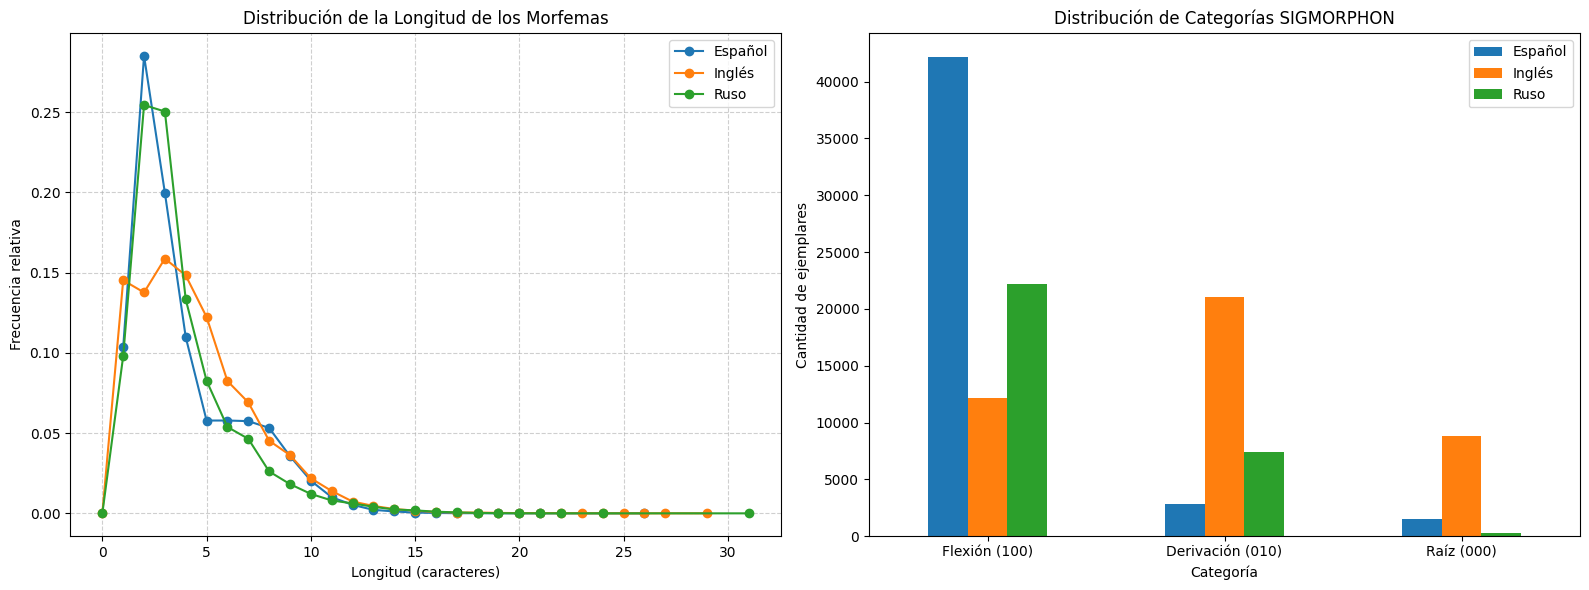

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

cat_data = {}

for iso, name in langs.items():
    raw = get_raw_corpus(iso)
    df_lang = raw_corpus_to_dataframe(raw, name)
    
    # --- Plot 1: Distribución de la longitud de los morfemas 
    all_morphs_len = [len(m.replace("@@", "")) for m_list in df_lang["morph"] for m in m_list]
    df_morph_len = pd.Series(all_morphs_len)
    
    counts = df_morph_len.value_counts(normalize=True).sort_index()
    ax1.plot(counts.index, counts.values, marker='o', label=name)
    
    # --- Preparación para Plot 2: Distribución de categorías 
    cat_counts = df_lang["category"].value_counts()
    cat_data[name] = {
        "Flexión (100)": cat_counts.get("100", 0),
        "Derivación (010)": cat_counts.get("010", 0),
        "Raíz (000)": cat_counts.get("000", 0)
    }

ax1.set_title("Distribución de la Longitud de los Morfemas")
ax1.set_xlabel("Longitud (caracteres)")
ax1.set_ylabel("Frecuencia relativa")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

df_cat = pd.DataFrame(cat_data)
df_cat.plot(kind='bar', ax=ax2)

ax2.set_title("Distribución de Categorías SIGMORPHON")
ax2.set_ylabel("Cantidad de ejemplares")
ax2.set_xlabel("Categoría")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

4. Con base en esta información, responde la pregunta: *¿Cuál de las tres lenguas se comporta más como una lengua aglutinante y cuál como una lengua aislante?*
    - Justifica tu respuesta usando tus métricas y figuras

A partir de la evidencia estadistica que recolecte de los puntos anteriores, puedo concluir lo siguiente:

-   **Lengua aislante**: *Ingles*

El ingles presenta el Ratio Morfemas/Palabra mas bajo de los tres. En la grafica se observa una alta frecuencia de palabras que consisten en un solo morfema (Raiz), es decir, no depende tanto de la afijacion para expresar significado gramatical.

-   **Lenguaje aglutinante**: *Ruso*

El ruso presenta el Ratio Morfemas/Palabra mas alto. El plot 1 muestra una curva desplazada a la derecha , indicando que sus palabras suelen estar compuestas por multiples segmentos. Es la que mas se acerca al comportamiento aglutinante debido a la gran cantidad de morfemas que concatena por palabra. 